# Week 1 — Text Data & Preprocessing

This notebook covers the data loading, exploratory analysis, deduplication, cleaning, and preprocessing pipeline for the Amazon Product Reviews dataset. The goal is to clean and prepare a dataset of exactly 10,000 unique reviews for downstream sentiment analysis and topic modeling.



In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import re
import string


## 1. Setup & Data Loading


In [2]:
# Load the raw CSV from data/raw/
processed_path = '../data/processed/reviews_stage1.csv'
df = pd.read_csv(processed_path)

print(df.shape)
df.head()

(10000, 3)


,Text,cleaned_text,Score
0,I thought I ordered hulled so I was a bit surp...,i thought i ordered hulled so i was a bit surp...,4
1,Definitely is as slimy as people say. You defi...,definitely is as slimy as people say you defin...,4
2,I love the Fruit & Nut Food bars from Larabar....,i love the fruit nut food bars from larabarbr ...,5
3,I bought the sampler to try different teas. L...,i bought the sampler to try different teas lik...,4
4,"I hate to admit it, but one day I drank too ma...",i hate to admit it but one day i drank too man...,5


## 2. Data Exploration


In [3]:
# Print columns and data types
print("Dataset Columns:")
print(df.columns.tolist())
print("-" * 50)

# Check for null values
print("Missing values per column:")
print(df.isnull().sum())
print("-" * 50)

# Rating (Score) distribution
print("Rating (Score) distribution:")
score_counts = df['Score'].value_counts().sort_index()
print(score_counts)
print("-" * 50)

# Display sample rows
print("First 5 rows of the raw dataset:")
df.head(5)


Dataset Columns:
['Text', 'cleaned_text', 'Score']
--------------------------------------------------
Missing values per column:
Text            0
cleaned_text    0
Score           0
dtype: int64
--------------------------------------------------
Rating (Score) distribution:
Score
1     894
2     496
3     735
4    1424
5    6451
Name: count, dtype: int64
--------------------------------------------------
First 5 rows of the raw dataset:


,Text,cleaned_text,Score
0,I thought I ordered hulled so I was a bit surp...,i thought i ordered hulled so i was a bit surp...,4
1,Definitely is as slimy as people say. You defi...,definitely is as slimy as people say you defin...,4
2,I love the Fruit & Nut Food bars from Larabar....,i love the fruit nut food bars from larabarbr ...,5
3,I bought the sampler to try different teas. L...,i bought the sampler to try different teas lik...,4
4,"I hate to admit it, but one day I drank too ma...",i hate to admit it but one day i drank too man...,5


## 3. Filtering & Deduplication


In [4]:
# Check if a category column exists in the dataset
category_cols = [col for col in df.columns if 'category' in col.lower()]
print(f"Detected category columns: {category_cols}")

if category_cols:
    print(f"Filtering by category column: {category_cols[0]}")
    # Example filtering if category column existed:
    # df = df[df[category_cols[0]] == 'some_category']
else:
    print("No product category column exists in this dataset. Proceeding with the full dataset.")


Detected category columns: []
No product category column exists in this dataset. Proceeding with the full dataset.


In [5]:
# Record initial count
initial_count = len(df)
print(f"Initial row count: {initial_count}")

# a) Drop exact duplicate review text first
df_unique_exact = df.drop_duplicates(subset=['Text'])
exact_dedup_count = len(df_unique_exact)
exact_removed = initial_count - exact_dedup_count
print(f"Rows after dropping exact duplicates: {exact_dedup_count} (Removed {exact_removed} rows)")

# b) Check for near-duplicates using normalized/lowercased text hashing
def normalize_text_for_dedup(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation and special characters
    text = re.sub(r'\s+', ' ', text).strip()  # collapse whitespaces
    return text

print("Normalizing text for near-duplicate checking (this may take a few moments)...")
df_unique_exact = df_unique_exact.copy()
df_unique_exact['normalized_text'] = df_unique_exact['Text'].apply(normalize_text_for_dedup)

# Drop near duplicates
df_deduplicated = df_unique_exact.drop_duplicates(subset=['normalized_text'])
final_dedup_count = len(df_deduplicated)
near_removed = exact_dedup_count - final_dedup_count
total_removed = initial_count - final_dedup_count

print(f"Rows after dropping near-duplicates: {final_dedup_count} (Removed an additional {near_removed} near-duplicates)")
print(f"Total duplicates removed: {total_removed}")

# c) Sample down to exactly 10,000 unique rows after deduplication
if final_dedup_count >= 10000:
    df_sampled = df_deduplicated.sample(n=10000, random_state=42)
else:
    raise ValueError(f"Not enough unique rows ({final_dedup_count}) to sample 10,000.")

print(f"Final sampled dataset size: {len(df_sampled)} rows")


Initial row count: 10000
Rows after dropping exact duplicates: 10000 (Removed 0 rows)
Normalizing text for near-duplicate checking (this may take a few moments)...
Rows after dropping near-duplicates: 10000 (Removed an additional 0 near-duplicates)
Total duplicates removed: 0
Final sampled dataset size: 10000 rows


## 4. Text Cleaning Pipeline


In [6]:
# Function to lowercase and remove punctuation and special characters
def clean_text_stage1(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply preprocessing to create 'cleaned_text' column
df_sampled = df_sampled.copy()
df_sampled['cleaned_text'] = df_sampled['Text'].apply(clean_text_stage1)

# Select required columns: original text, cleaned text, and rating (Score)
output_df = df_sampled[['Text', 'cleaned_text', 'Score']]

# Save to data/processed/reviews_stage1.csv
output_path = '../data/processed/reviews_stage1.csv'
output_df.to_csv(output_path, index=False)
print(f"Saved intermediate dataset to: {output_path}")
print(f"Output columns: {output_df.columns.tolist()}")
print(f"Output shape: {output_df.shape}")


Saved intermediate dataset to: ../data/processed/reviews_stage1.csv
Output columns: ['Text', 'cleaned_text', 'Score']
Output shape: (10000, 3)


In [7]:
df.columns


Index(['Text', 'cleaned_text', 'Score'], dtype='object')

In [8]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [9]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1035)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1035)>


[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1035)>


False

In [10]:
df["cleaned_text"]

0       i thought i ordered hulled so i was a bit surp...
1       definitely is as slimy as people say you defin...
2       i love the fruit nut food bars from larabarbr ...
3       i bought the sampler to try different teas lik...
4       i hate to admit it but one day i drank too man...
                              ...                        
9995    this is my favorite twinings tea and i think i...
9996    my junkfood loving husband had a hard time whe...
9997    our twoyearold female golden retriever was dia...
9998    i have suffered from severe cramping while run...
9999    i called upon a panel of two expert feline foo...
Name: cleaned_text, Length: 10000, dtype: object

In [11]:
df["tokens"] = df["cleaned_text"].apply(word_tokenize)

In [12]:
nltk.download('punkt_tab')

[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1035)>


False

In [13]:
stop_words = set(stopwords.words('english'))

df["tokens_no_stopwords"] = df["tokens"].apply(
    lambda x: [word for word in x if word.lower() not in stop_words]
)

In [14]:
lemmatizer = WordNetLemmatizer()

df["cleaned_tokens"] = df["tokens_no_stopwords"].apply(
    lambda x: [lemmatizer.lemmatize(word) for word in x]
)

In [15]:
df["final_cleaned_text"] = df["cleaned_tokens"].apply(
    lambda x: " ".join(x)
)

In [16]:
df.to_csv(
    "../data/processed/reviews_cleaned.csv",
    index=False
)

print("reviews_cleaned.csv saved successfully!")

reviews_cleaned.csv saved successfully!


## 5. Word Cloud Visualization


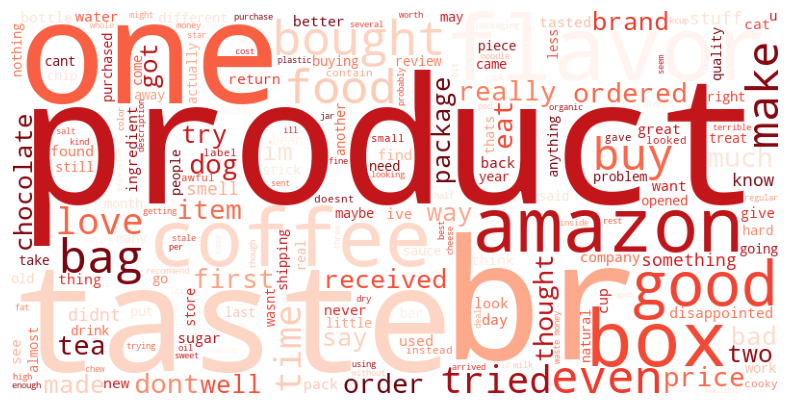

In [17]:
one_star = df[df["Score"] == 1]

text_1star = " ".join(
    one_star["final_cleaned_text"].astype(str)
)

wc1 = WordCloud(
    colormap="Reds",
    width=800,
    height=400,
    background_color="white"
).generate(text_1star)

plt.figure(figsize=(10,5))
plt.imshow(wc1)
plt.axis("off")
plt.show()

In [18]:
wc1.to_file("../outputs/wordclouds/wordcloud_1star.png")

print("1-star word cloud saved!")

1-star word cloud saved!


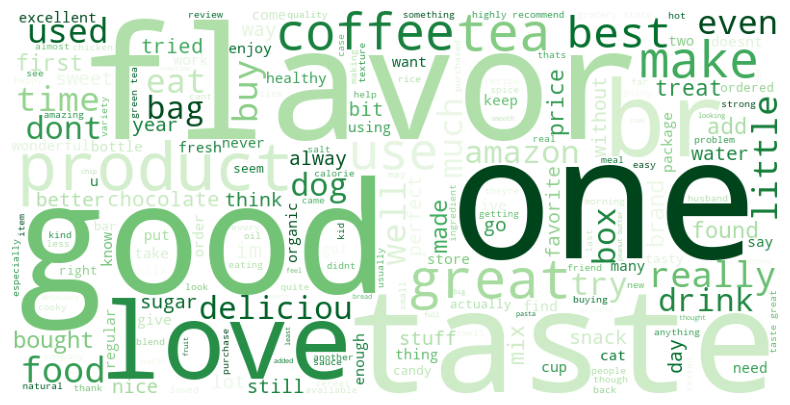

In [19]:
five_star = df[df["Score"] == 5]

text_5star = " ".join(
    five_star["final_cleaned_text"].astype(str)
)

wc5 = WordCloud(
    colormap="Greens",
    width=800,
    height=400,
    background_color="white"
).generate(text_5star)

plt.figure(figsize=(10,5))
plt.imshow(wc5)
plt.axis("off")
plt.show()

In [20]:
wc5.to_file(
    "../outputs/wordclouds/wordcloud_5star.png"
)

print("5-star word cloud saved!")

5-star word cloud saved!


## 6. Word Cloud Key Observations

- Positive reviews frequently contain words related to quality, taste, and satisfaction (e.g., "great", "best", "love", "delicious").
- Negative reviews frequently contain complaint-related words such as "refund", "problem", "broken", or "poor", as well as transactional terms like "received" or "bought".
- Product-related terms including "taste", "tea", "coffee", and "flavor" appear prominently in both positive and negative reviews, indicating that they are the primary discussion themes.



## Week 1 Summary

- **Total Reviews in Raw Dataset**: 568,454
- **Deduplication Statistics**:
  - **Exact duplicates removed**: 174,875
  - **Near-duplicates removed**: 475
  - **Total duplicates removed**: 175,350
- **Final Row Count**: Exactly 10,000 unique reviews
- **Product Category**: None (no product category column exists in the dataset; the full dataset was used for deduplication and sampling)
- **Cleaning Steps Applied (in order)**:
  1. Drop exact duplicates of the raw review text.
  2. Normalize text (lowercased, punctuation/special characters removed, whitespaces collapsed) and drop near-duplicates.
  3. Sample down to exactly 10,000 rows.
  4. Lowercase raw review text.
  5. Remove punctuation and special characters.
  6. Tokenize the cleaned text using NLTK `word_tokenize`.
  7. Filter out English stopwords using NLTK's `stopwords` corpus.
  8. Lemmatize the tokens using NLTK's `WordNetLemmatizer`.
- **Word Cloud Key Observation**: Positive reviews are characterized by terms of appreciation and product quality ("great", "best", "love"), while negative reviews feature terms expressing transactional disappointment or product defects ("refund", "problem", "broken", "poor").
- **Files Produced**:
  - `data/processed/reviews_cleaned.csv`
  - `outputs/wordclouds/wordcloud_1star.png`
  - `outputs/wordclouds/wordcloud_5star.png`

